# LSI31003 Machine Learning in Molecular Biology
## Peptide classification group project

### Introduction:
In Assignment 3, you learned how pretrained transformer models could be used to learn embeddings for short peptide sequences, and how those embeddings could then be further used in downstream machine learning tasks. In assignment 3 we built a classifier to predict whether a given short peptide was of antimicrobial origin (AMP) vs non-Antimicrobial (nonAMP), based on the information contained within its sequence alone.

However, short peptide sequences have also other important functionality in living organisms than just Antimicrobial effects. In this group assignment, you will investigate peptides with multiple biological functionalities. 

Dataset comes from a curated short peptide collection described in (Xiao, B. *et al.*): **A comprehensive dataset of therapeutic peptides on multi-function property and structure information** (https://doi.org/10.1038/s41597-025-05528-1). Read the paper to find further details on how the peptides are classified (main and subcategories), as well as descriptions for the peptide metadata table.

For this task, we have calculated the ESM-2 embeddings for you in advance. All performed preprocessing steps are described in Peptide_project_preprocessing.ipynb. Furthermore, there is a second set of embeddings that is further derived from ESM-2 embeddings using supervised learning methods (known labels) with a deep learning framework (with combination of autoencoder-like reproducibility loss and prediction accuracy for the target label vector). You can use this set of embeddings as well, but if you are familiar with deep learning libraries such as pytorch and tensorflow, it's higly recommended that you try to learn suitable optimized embeddings yourself (but this is not a necessity)! The raw ESM-2 embeddings might also work on their own, but it's up to you to decide/ try out.

### Your task:
Your task is to built a classifier that predicts the peptide classes with as good accuracy as possible, mainly using the embedding representations as inputs (feel free to try other feature engineering methods as well if you like!). Apply dimensionsionality reduction methods if deemed appropriate. You should first make the classifier for the 15 main categories. After that, you can also try to predict the subcategories within each main peptide category. You should do model selection and show performance with confusion matrix visualizations and/or other general accuracy metrics.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# your library imports

In [3]:
# peptides with available metadata

meta = pd.read_csv("./data/Peptide_Metadata.csv", index_col = 0)
print(f"{meta.shape[0]} total peptides.")
meta.head(5)

17265 total peptides.


,Function,Label encoding,Sequence,Source,Is_natural_peptide,HELM notation,N-terminal modification,C-terminal modification,Post translation modifications,Reference
ID,,,,,,,,,,
100004,"Antimicrobial|Antibacterial|Anti-gram+,Antimic...","[0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",AAAAAAAAAAGIGKFLHSAKKFGKAFVGEIMNS,Human,True,PEPTIDE1{[ac].A.A.A.A.A.A.A.A.A.A.G.I.G.K.F.L....,NaN,NaN,NaN,"Antimicrob Agents Chemother, 1992, 36, 313;PMI..."
100007,"Antimicrobial|Antibacterial|Anti-gram+,Antimic...","[0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",AAAAAAAIKMLMDLVNERIMALNKKAKK,virus (Bovine papular stomatitis virus)|Bovine...,True,PEPTIDE1{[ac].A.A.A.A.A.A.A.I.K.M.L.M.D.L.V.N....,NaN,NaN,NaN,"PLoS One, 2012, 7, e45848;PMID: 23029273"
100013,"Antimicrobial|Antibacterial|Anti-gram+,Antimic...","[0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",AAAAGSCVWGAVNYTSDCAAECKRRGYKGGHCGSFANVNCWCET,ND,True,PEPTIDE1{[ac].A.A.A.A.G.S.C.V.W.G.A.V.N.Y.T.S....,NaN,NaN,NaN,"Biochemistry, 2001, 40, 11995;PMID: 11580275"
100014,"Antimicrobial|Antibacterial|Anti-gram+,Antimic...","[0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",AAAAGSCVWGAVNYTSDCAAECKRRGYKGGHCGSFANVNCWCRT,ND,True,PEPTIDE1{[ac].A.A.A.A.G.S.C.V.W.G.A.V.N.Y.T.S....,NaN,NaN,NaN,"Biochemistry, 2001, 40, 11995;PMID: 11580275"
100015,"Antimicrobial|Antibacterial|Anti-gram+,Antimic...","[0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",AAAAGSCVWGAVNYTSDCAAECLLRGYKGGHCGSFANVNCWCET,ND,True,PEPTIDE1{[ac].A.A.A.A.G.S.C.V.W.G.A.V.N.Y.T.S....,NaN,NaN,NaN,"Biochemistry, 2001, 40, 11995;PMID: 11580275"


In [4]:
# Embeddings from ESM2-model (same pipeline as in Assignment 3)

embeddings_esm = pd.read_csv("./data/Embeddings_Esm2.csv", index_col = 0)
print(f"{embeddings_esm.shape[1]} dimensional peptide embeddings from ESM-2 model")
embeddings_esm.head()

1280 dimensional peptide embeddings from ESM-2 model


,0,1,2,3,4,5,6,7,8,9,...,1270,1271,1272,1273,1274,1275,1276,1277,1278,1279
ID,,,,,,,,,,,,,,,,,,,,,
100004,-0.002897,0.032261,-0.061632,-0.012294,0.083954,-0.027361,-0.064955,0.041762,-0.006667,-0.117269,...,0.030947,-0.058636,-0.084253,0.144039,0.056908,0.058979,0.020752,0.068330,-0.123524,0.092439
100007,-0.021438,-0.036954,-0.018984,-0.015381,0.001480,-0.057479,-0.045701,0.061801,0.001520,-0.123927,...,0.036371,-0.038882,-0.012545,0.093841,0.050679,0.047878,0.106075,-0.061094,-0.028786,0.008304
100013,-0.010459,-0.011805,0.022508,0.043741,0.000519,0.033871,0.051326,-0.015819,0.054000,0.081105,...,0.080855,0.000629,0.045531,-0.001710,-0.054935,-0.035005,0.033414,-0.098053,-0.008366,0.099628
100014,-0.029972,-0.022473,0.018484,0.042649,-0.010375,0.047744,0.059621,-0.011444,0.034726,0.089829,...,0.074273,-0.021156,0.043835,0.022560,-0.047037,-0.015590,0.029909,-0.103113,0.008463,0.077277
100015,-0.011639,-0.005451,0.037088,0.048091,0.013870,0.033050,0.023372,0.010481,0.066343,0.064727,...,0.087427,0.014022,0.045259,-0.006255,-0.051198,-0.025632,0.039032,-0.091726,-0.007044,0.110314


In [5]:
# Mystery embeddings: derivation from ESM-embeddings optimized with deeplearning methods and known labels.

embeddings_finetuned = pd.read_csv("./data/Embeddings_Mysteryengineered.csv", index_col = 0)
print(f"{embeddings_finetuned.shape[1]} dimensional peptide embeddings downstream engineered from ESM-2 model")
embeddings_finetuned.head()

200 dimensional peptide embeddings downstream engineered from ESM-2 model


,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
ID,,,,,,,,,,,,,,,,,,,,,
100004,-0.483709,-0.557164,-0.420388,-0.175160,0.793239,0.120372,-0.146778,0.119034,0.344554,0.565946,...,0.154780,-0.338444,-0.211424,0.650465,0.168623,0.403776,0.295616,-0.637571,-0.235686,-0.062087
100007,-0.384557,-0.158466,-0.540723,-0.139707,0.417634,0.441971,-0.197034,0.160257,0.352310,0.503866,...,0.320291,-0.296480,-0.400126,0.744250,0.055119,0.386485,0.189654,-0.393325,-0.190110,-0.113808
100013,-0.444259,0.233969,-0.649846,-0.301525,0.378391,0.652291,0.120221,0.060428,0.113184,0.017043,...,0.378905,-0.317880,-0.147875,0.019434,0.200457,0.386632,0.220315,-0.026951,0.105835,-0.316225
100014,-0.447115,0.242742,-0.640375,-0.313176,0.381286,0.642577,0.129668,0.057654,0.108229,0.009943,...,0.386476,-0.319757,-0.132476,-0.004574,0.210770,0.409565,0.223644,-0.020175,0.093596,-0.305084
100015,-0.435927,0.249961,-0.656335,-0.319148,0.338178,0.657516,0.122982,0.063526,0.093505,0.011224,...,0.391172,-0.316295,-0.174601,0.020248,0.212861,0.350936,0.193509,-0.018062,0.098034,-0.329183


**Labels -table columns:**  
`MAIN_category` one of the main 15 categories defined in the table (or "Multipurpose" if peptide belongs to multiple categories).  
`isSinglepurpose`: True if only 1 main category, False if MAIN_Category = "Multipurpose"  
`other columns`: Other peptide subtypes from the paper, corresponding to `Label encoding` -column of the meta table.

In [6]:
labels = pd.read_csv("./data/Peptide_Targetlabels.csv", index_col = 0)
labels.head()

,MAIN_Category,isSinglepurpose,Analgesic,Angiogenic,Anti-gram+,Anti-gram-,AntiAngiogenesis,AntiBreastcancer,AntiCervicalcancer,AntiColoncancer,...,Growth_regulatory,Immunoactive,Lipid_metabolism,Metabolic_regulatory,Neuropeptide,Opioid,Osteogenic,Quorum_sensing,Thrombolytic,Tumor_homing
ID,,,,,,,,,,,,,,,,,,,,,
100004,Antibacterial,True,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
100007,Antibacterial,True,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
100013,Multipurpose,False,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
100014,Multipurpose,False,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
100015,Multipurpose,False,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**my work**

### Data exploration

Antimicrobial           4916
Multipurpose            4413
Antibacterial           3740
Antiviral               1460
Neuropeptide            1010
Antifungal               509
Metabolic_regulatory     406
Antiparasitic            230
Cell_Communication       226
Anticancer               100
Drug_delivery             73
Antihypertensive          73
Growth_regeneration       65
Immunoactive              27
Antioxidant               14
Thrombolytic               3
Name: MAIN_Category, dtype: int64


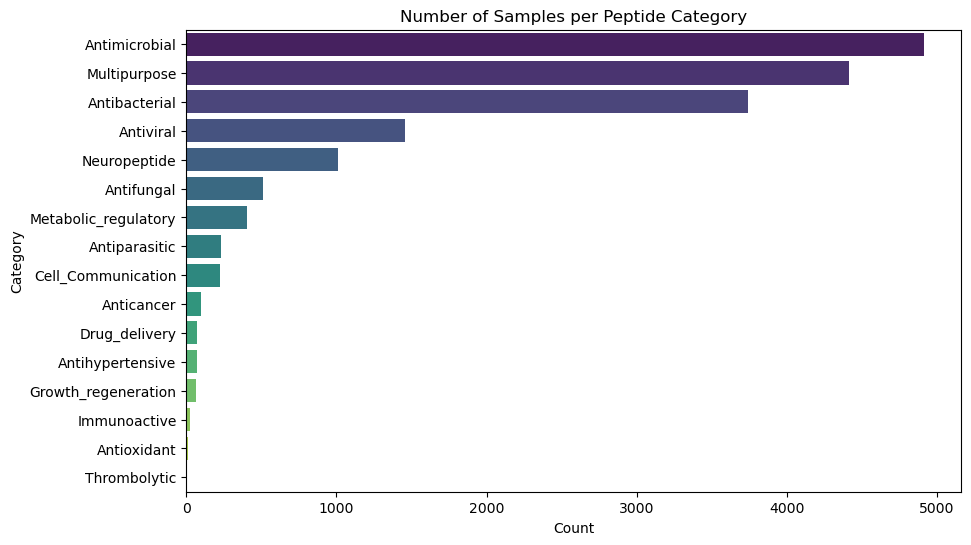

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the exact counts
category_counts = labels['MAIN_Category'].value_counts()
print(category_counts)

# 2. Visualize the distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')
plt.title('Number of Samples per Peptide Category')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

### First approach: MAIN Category classification with random forest

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# It is best practice to scale data before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(embeddings_finetuned)

# Keep 95% of the variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"Original dimensions: {X_scaled.shape[1]}")
print(f"Reduced dimensions: {X_pca.shape[1]}")

Original dimensions: 200
Reduced dimensions: 14


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Encode string labels into numbers
le = LabelEncoder()
y_main = le.fit_transform(labels['MAIN_Category'])

# Split the data (stratify ensures proportional class representation in the test set)
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_main, test_size=0.2, random_state=42, stratify=y_main
)

# Initialize model with 'balanced' class weights to handle your imbalanced data
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

                      precision    recall  f1-score   support

       Antibacterial       0.68      0.72      0.70       748
          Anticancer       1.00      0.10      0.18        20
          Antifungal       0.83      0.72      0.77       102
    Antihypertensive       0.25      0.07      0.11        15
       Antimicrobial       0.84      0.87      0.85       983
         Antioxidant       0.00      0.00      0.00         3
       Antiparasitic       0.88      0.61      0.72        46
           Antiviral       0.92      0.83      0.87       292
  Cell_Communication       0.81      0.29      0.43        45
       Drug_delivery       1.00      0.20      0.33        15
 Growth_regeneration       0.50      0.08      0.13        13
        Immunoactive       1.00      0.20      0.33         5
Metabolic_regulatory       0.79      0.68      0.73        81
        Multipurpose       0.63      0.64      0.64       882
        Neuropeptide       0.66      0.84      0.74       202
       

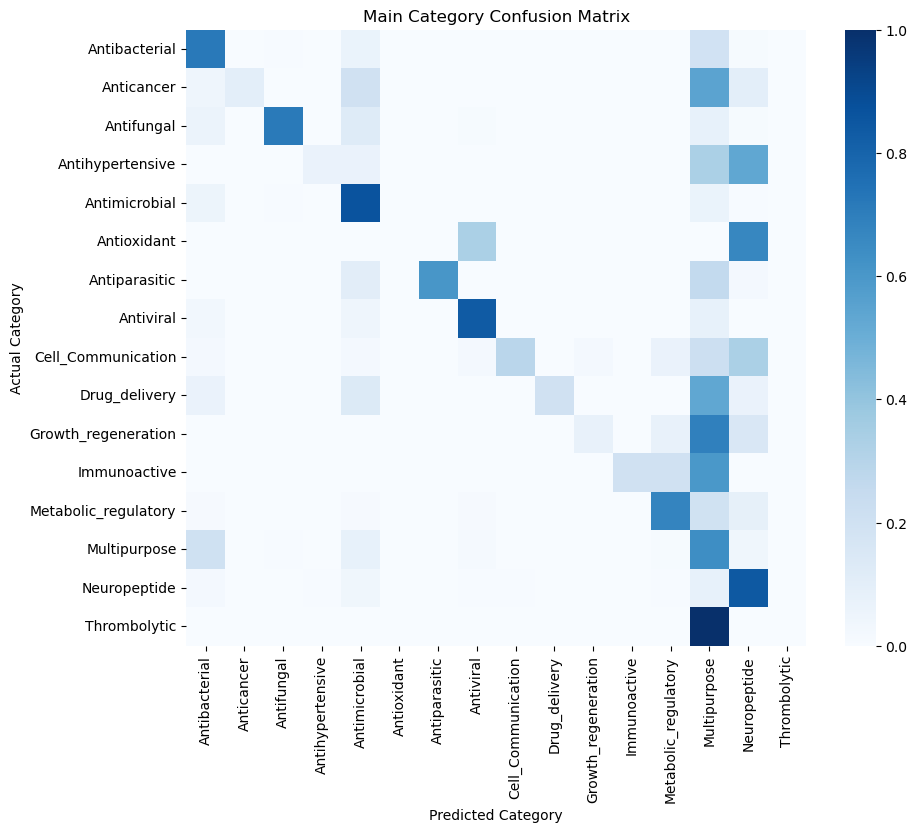

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = rf_model.predict(X_test)

# 1. Print detailed text metrics
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

# 2. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.title('Main Category Confusion Matrix')
plt.show()

Having confusion between multipurpose and other categories is expected due to them having functions of the other categories. Additionally we can see confusion between antimicrobial and antibacterial, anticancer, antifungal, antiviral categories, which can araise from all of them having immunity related functions, increasing their similarity. Also many cell communication, metabolic regulation and antihypertensive peptides have been classified as neuropeptides, as most of them are signnaling peptides, having structural similarity. Outside of these few high-confusion clusters, the algorithm provides fairly accurate predictions across the categories.

### Second approach: MAIN category classification with logistic regression

In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# It is best practice to scale data before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(embeddings_finetuned)

# Keep 95% of the variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"Original dimensions: {X_scaled.shape[1]}")
print(f"Reduced dimensions: {X_pca.shape[1]}")

Original dimensions: 200
Reduced dimensions: 14


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
# Encode string labels into numbers
le = LabelEncoder()
y_main = le.fit_transform(labels['MAIN_Category'])

# Split the data (stratify ensures proportional class representation in the test set)
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_main, test_size=0.2, random_state=42, stratify=y_main
)

# Initialize model with 'balanced' class weights to handle your imbalanced data
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# Initialize logistic regression
lr_model = LogisticRegression(
    solver='lbfgs',            # Supports multinomial
    class_weight='balanced',   # Handle imbalance
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

                      precision    recall  f1-score   support

       Antibacterial       0.66      0.67      0.66       748
          Anticancer       0.04      0.40      0.08        20
          Antifungal       0.47      0.82      0.60       102
    Antihypertensive       0.08      0.53      0.14        15
       Antimicrobial       0.89      0.74      0.81       983
         Antioxidant       0.00      0.00      0.00         3
       Antiparasitic       0.22      0.78      0.35        46
           Antiviral       0.84      0.82      0.83       292
  Cell_Communication       0.28      0.49      0.35        45
       Drug_delivery       0.18      0.73      0.29        15
 Growth_regeneration       0.18      0.77      0.29        13
        Immunoactive       0.08      1.00      0.15         5
Metabolic_regulatory       0.64      0.80      0.71        81
        Multipurpose       0.57      0.24      0.34       882
        Neuropeptide       0.78      0.49      0.60       202
       

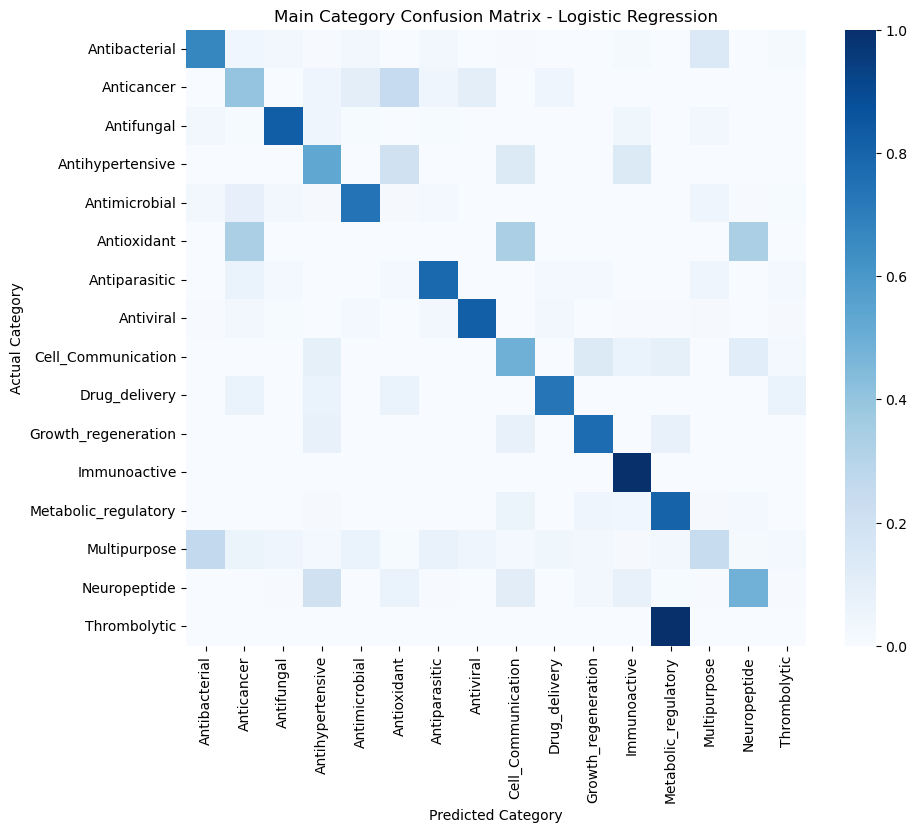

In [19]:
#logistic regression plotting 
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict using Logistic Regression model
y_pred = lr_model.predict(X_test)

# 1. Print detailed text metrics
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_,
    zero_division=0
))

# 2. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=False,
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.title('Main Category Confusion Matrix - Logistic Regression')
plt.show()

### Fird approach: Multilabel classification with random forest

Since multipurpose label means that the peptide has in fact mor main labels, multilabel classification approach was tried to classify peptide to all possible labels from MAIN category. To do that, first labels were cleaned out from ones accounting for <1%of total dataset (6 labels removed). Next, iteractive stratification for multilabel classification has been used, along with different models (decision trees, random forest, bagging classifier and SVM), among which Random Forest showed best overall performance. The best model shows 0.63 overall accuracy and, as expected, worked better for more abundant categories (such as Antimicrobial), while for less abundant it was mostly returning 0 as prediction. All models has been working better on full finetuned embeddings as an input, than on PCA components derived from them.

In [7]:
# all the main categories are within columns (containing main + subcategories)
# selection of df to contain only main categories, where 'Multipurpose' peptides will have multiple labels

cats = list(labels.MAIN_Category.unique())
cats.remove('Multipurpose')
print(cats)

labels_main_multicat = labels.loc[:, cats]

print(embeddings_finetuned.shape)
print(labels_main_multicat.shape)

# sum labels in each category 
labels_sum = labels_main_multicat.sum(axis=0)

# remove labels accounting to <1% of dataset
labels_to_keep = labels_sum[labels_sum >= sum(labels_sum)*0.01]
print(labels_to_keep.index)

labels_main_multicat = labels_main_multicat.loc[:, labels_to_keep.index]
print(labels_main_multicat.shape)

['Antibacterial', 'Metabolic_regulatory', 'Antimicrobial', 'Anticancer', 'Growth_regeneration', 'Antiviral', 'Cell_Communication', 'Neuropeptide', 'Drug_delivery', 'Antihypertensive', 'Antifungal', 'Antiparasitic', 'Antioxidant', 'Thrombolytic', 'Immunoactive']
(17265, 200)
(17265, 15)
Index(['Antibacterial', 'Metabolic_regulatory', 'Antimicrobial', 'Anticancer',
       'Antiviral', 'Cell_Communication', 'Neuropeptide', 'Antifungal',
       'Antiparasitic'],
      dtype='object')
(17265, 9)


CM:
[[[2879  212]
  [ 191 1897]]

 [[4975   13]
  [  51  140]]

 [[3397  130]
  [ 280 1372]]

 [[4728   29]
  [ 318  104]]

 [[4355   53]
  [ 323  448]]

 [[4942   39]
  [ 128   70]]

 [[4643  107]
  [ 117  312]]

 [[4064  205]
  [ 449  461]]

 [[5000   20]
  [ 116   43]]]
Model Accuracy: 0.6447190577331531
Classification Report:               precision    recall  f1-score   support

           0       0.90      0.91      0.90      2088
           1       0.92      0.73      0.81       191
           2       0.91      0.83      0.87      1652
           3       0.78      0.25      0.37       422
           4       0.89      0.58      0.70       771
           5       0.64      0.35      0.46       198
           6       0.74      0.73      0.74       429
           7       0.69      0.51      0.59       910
           8       0.68      0.27      0.39       159

   micro avg       0.86      0.71      0.78      6820
   macro avg       0.80      0.57      0.65      6820
weighted avg      

/home/iganiemi/anaconda3/envs/ml-for-molbio/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/iganiemi/anaconda3/envs/ml-for-molbio/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/iganiemi/anaconda3/envs/ml-for-molbio/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(aver

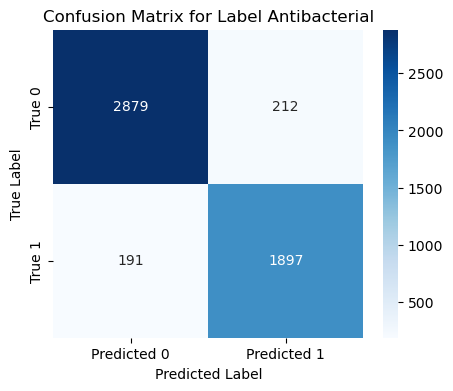

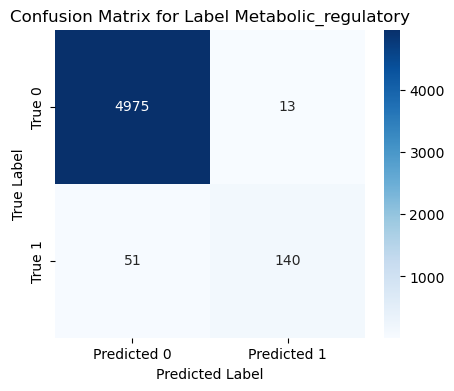

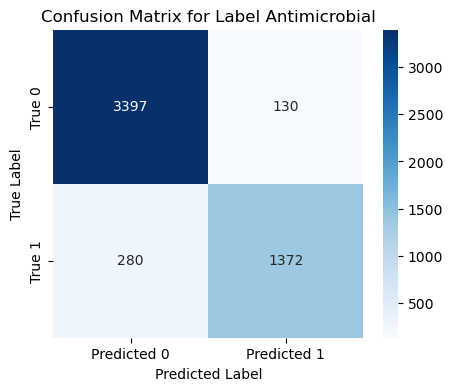

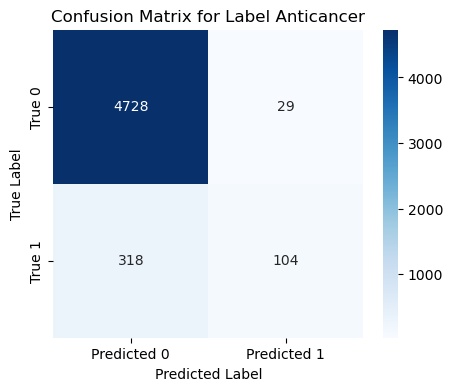

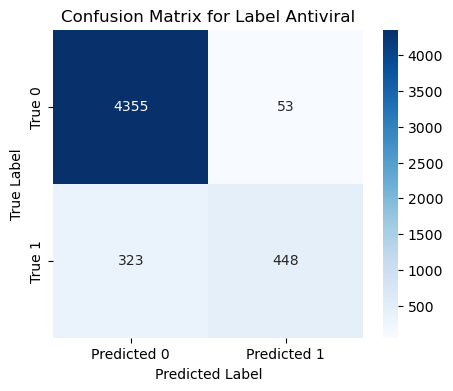

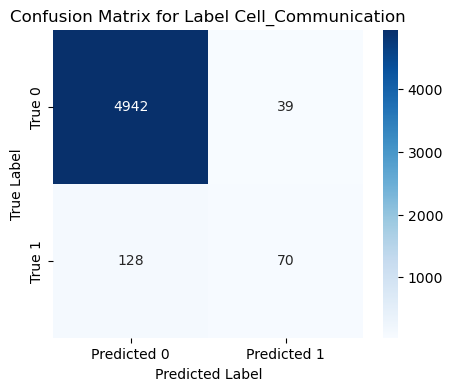

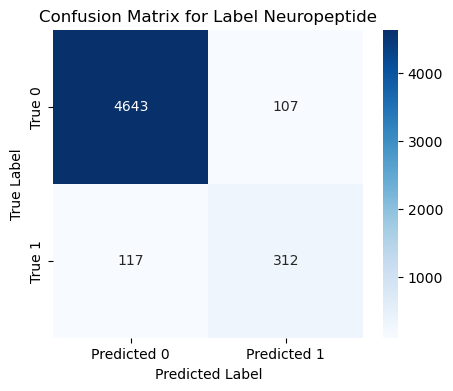

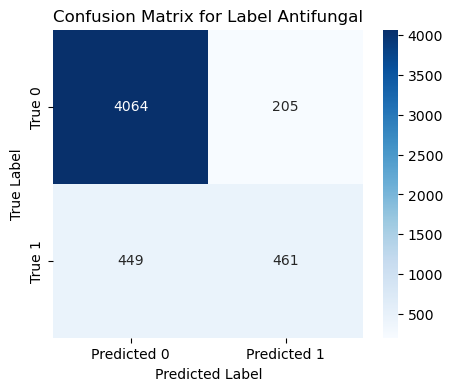

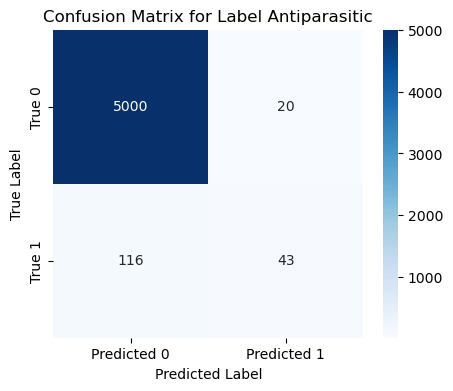

In [14]:
from sklearn.model_selection import train_test_split
from skmultilearn.model_selection import iterative_train_test_split, IterativeStratification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, multilabel_confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

X = embeddings_finetuned
y = labels_main_multicat

# alternative stratification for multiclass
stratifier = IterativeStratification(n_splits=2, order=1, sample_distribution_per_fold=[0.3, 0.7, ])
train_indices, test_indices = next(stratifier.split(X, y))
X_train, y_train = X.iloc[train_indices, :], y.iloc[train_indices, :]
X_test, y_test = X.iloc[test_indices, :], y.iloc[test_indices, :]

# make classifier
#dtree = DecisionTreeClassifier(max_depth=6, random_state=42) # best acc 0.53
dtree = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # best acc 0.63
#dtree = BaggingClassifier() # best acc 0.58, very slow
#dtree = SVC(kernel='rbf', C=1, random_state=42) # best acc 0.62

# make multipoutput classifier, fit the model, predict, compute metrics
dtree_multi = MultiOutputClassifier(dtree)
dtree_multi.fit(X_train, y_train)
dtree_preds = dtree_multi.predict(X_test)
dtree_acc = accuracy_score(y_test, dtree_preds)
dtree_cm = multilabel_confusion_matrix(y_test, dtree_preds)
dtree_cr = classification_report(y_test, dtree_preds)

print('CM:')
print(dtree_cm)

print("Model Accuracy:", dtree_acc)

print('Classification Report:', dtree_cr)

# generate and plot confusion matrices for each label
for i in range(y.shape[1]):  # Iterate through each label
    cm = confusion_matrix(y_test.iloc[:, i], dtree_preds[:, i])
    #cm = confusion_matrix(y_test.iloc[:, i], dtree_preds[:, i], normalize='true') # normalised
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', # fmt=".2f"
                xticklabels=['Predicted 0', 'Predicted 1'], 
                yticklabels=['True 0', 'True 1'])
    plt.title(f'Confusion Matrix for Label {y.columns[i]}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


### Forth approach: subcategory classification with random forest

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [12]:
# Remove Rare Subcategories
# Some subcategories had extremely low representation (<20 samples), which makes supervised learning unreliable. 
# Therefore, we restricted the analysis to sufficiently represented subcategories to obtain meaningful performance metrics.

# Count positives per label
label_counts = labels.drop(columns=["MAIN_Category", "isSinglepurpose"]).sum()

# Keep only labels with at least 20 samples
valid_labels = label_counts[label_counts >= 20].index

print("Number of subcategories kept:", len(valid_labels))

# New target matrix
y_filtered = labels[valid_labels].values

# 1. Identify subcategory columns
# X = embeddings
X = embeddings_esm.values

# y = all subcategory columns (drop the first two columns)
y = labels.drop(columns=["MAIN_Category", "isSinglepurpose"]).values

# 2. Train–Test Split

from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# train Multi-Label Model
model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=3000
    )
)

model.fit(X_train, y_train)

import numpy as np

# Get probability predictions
y_proba = model.predict_proba(X_test)

# Apply custom Threshold
threshold = 0.3
y_pred_custom = (y_proba >= threshold).astype(int)

# Evaluate Model Performance
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_custom))

# Inspect Label Distribution
label_counts = labels.drop(columns=["MAIN_Category", "isSinglepurpose"]).sum()
label_counts.sort_values(ascending=False).head(10)


Number of subcategories kept: 43
X_train shape: (13812, 1280)
X_test shape: (3453, 1280)
y_train shape: (13812, 48)
y_test shape: (3453, 48)


/home/iganiemi/anaconda3/envs/ml-for-molbio/lib/python3.10/site-packages/sklearn/multiclass.py:90: UserWarning: Label not 1 is present in all training examples.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.88      0.64      0.74        11
           1       0.00      0.00      0.00         0
           2       0.55      0.80      0.65      1043
           3       0.57      0.78      0.66      1014
           4       1.00      0.09      0.17        11
           5       0.50      0.17      0.25        18
           6       1.00      0.10      0.18        10
           7       0.50      0.33      0.40         9
           8       1.00      0.55      0.71        11
           9       0.92      0.72      0.81       202
          10       0.67      0.13      0.22        15
          11       0.00      0.00      0.00         1
          12       1.00      0.09      0.17        11
          13       0.80      0.40      0.53        10
          14       1.00      0.25      0.40         4
          15       0.77      0.59      0.67        29
          16       0.50      0.36      0.42        11
          17       0.00    

/home/iganiemi/anaconda3/envs/ml-for-molbio/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/iganiemi/anaconda3/envs/ml-for-molbio/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/iganiemi/anaconda3/envs/ml-for-molbio/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(aver

Antibacterial         6959
Antimicrobial         5507
Anti-gram+            5137
Anti-gram-            4926
Antifungal            3034
Antiviral             2570
Neuropeptide          1430
Anticancer            1407
AntiHIV                900
Cell_Communication     659
dtype: int64

## Final Model Evaluation and Interpretation

The subcategory prediction task was formulated as a multi-label classification problem, since a peptide can belong to multiple biological subcategories simultaneously.

We trained a One-vs-Rest Logistic Regression model using precomputed ESM-2 embeddings as input features.

Due to strong class imbalance across subcategories (e.g., Antibacterial and Antimicrobial dominating the dataset while several categories have very few samples), we adjusted the probability decision threshold from the default 0.5 to 0.3. 

This improved recall and overall F1-score without introducing excessive false positives.

## Final Performance:

Micro F1-score: 0.63

Weighted F1-score: 0.61

Macro F1-score: 0.39

### The model performs well on highly represented subcategories, while performance on rare categories remains limited due to insufficient training sample